# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [ ]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df_genes = pd.read_csv("./data/df_genes_aula6exer7.csv", index_col="Unnamed: 0")
df_genes.head()

,num_letras,primeiras_duas_letras,num_a,contains_hu
isg15,5,is,0,False
hur,3,hu,0,True
ifna,4,if,1,False
tnfa,4,tn,1,False
atpsf1a,7,at,2,False


In [78]:
df_genes['id_entrez'] = [
    "NM_005101.4",
    "NM_001419.3",
    "NM_024013.3",
    "NM_001270508.2",
    "NM_004046.6",
]

df_genes['id_protein'] = [
    'NP_005092.1',
    "NP_001410.2",
    "NP_000596.2",
    "NP_001257437.1",
    "NP_004037.1",
]
df_genes

,num_letras,primeiras_duas_letras,num_a,contains_hu,id_entrez,id_protein
isg15,5,is,0,False,NM_005101.4,NP_005092.1
hur,3,hu,0,True,NM_001419.3,NP_001410.2
ifna,4,if,1,False,NM_024013.3,NP_000596.2
tnfa,4,tn,1,False,NM_001270508.2,NP_001257437.1
atpsf1a,7,at,2,False,NM_004046.6,NP_004037.1


In [ ]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    Entrez.email = "seu@email.com"
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()
    with open(f"./exercicios/data/{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [ ]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

isg15 NP_005092.1
hur NP_001410.2
ifna NP_000596.2
tnfa NP_001257437.1
atpsf1a NP_004037.1


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [1]:
import pandas as pd

dados = {
    'num_letras': [5, 3, 4, 4, 7],
    'primeiras_duas_letras': ['is', 'hu', 'if', 'tn', 'at'],
    'num_a': [0, 0, 1, 1, 2],
    'contains_hu': [False, True, False, False, False]
}

df = pd.DataFrame(dados, index=['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'])

print("Frequência absoluta por coluna:")
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

Frequência absoluta por coluna:

num_letras:
num_letras
4    2
5    1
3    1
7    1
Name: count, dtype: int64

primeiras_duas_letras:
primeiras_duas_letras
is    1
hu    1
if    1
tn    1
at    1
Name: count, dtype: int64

num_a:
num_a
0    2
1    2
2    1
Name: count, dtype: int64

contains_hu:
contains_hu
False    4
True     1
Name: count, dtype: int64


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [2]:
import pandas as pd

df = pd.DataFrame({
    'valina': [2, 0, 1, 3, 1]
}, index=['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'])

print(df)
print(f"\nMaior: {df['valina'].idxmax()} ({df['valina'].max()})")

         valina
isg15         2
hur           0
ifna          1
tnfa          3
atpsf1a       1

Maior: tnfa (3)


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [1]:
import pandas as pd

# Exemplo com dados de serina
df = pd.DataFrame({'serina': [2, 3, 1, 4, 2, 3, 0, 2, 1, 3]})

print(f"Média: {df['serina'].mean():.2f}")
print(f"Mediana: {df['serina'].median()}")
print(f"Moda: {df['serina'].mode()[0]}")

Média: 2.10
Mediana: 2.0
Moda: 2


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

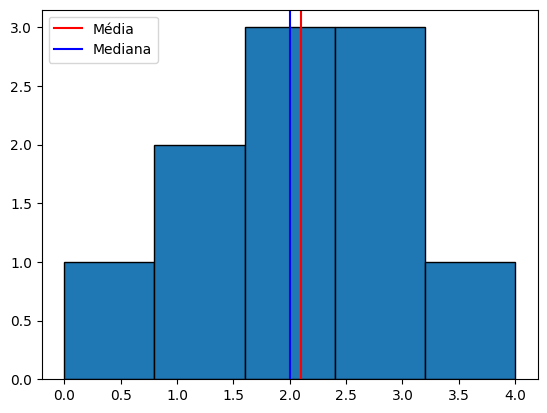

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({'serina': [2, 3, 1, 4, 2, 3, 0, 2, 1, 3]})

plt.hist(df['serina'], bins=5, edgecolor='black')
plt.axvline(df['serina'].mean(), color='red', label='Média')
plt.axvline(df['serina'].median(), color='blue', label='Mediana')
plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

Média: 2.10
Mediana: 2.0


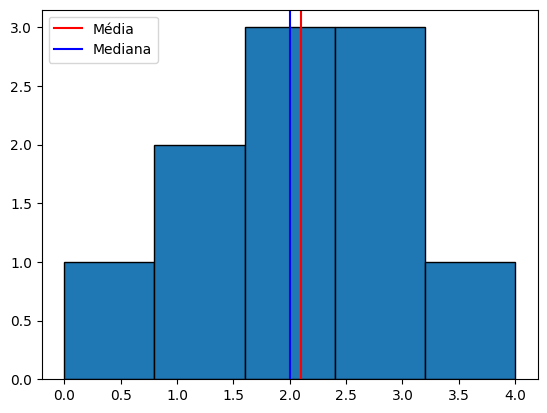

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def analisar_aa(df, aa):
    print(f"Média: {df[aa].mean():.2f}")
    print(f"Mediana: {df[aa].median()}")
    
    plt.hist(df[aa], bins=5, edgecolor='black')
    plt.axvline(df[aa].mean(), color='red', label='Média')
    plt.axvline(df[aa].median(), color='blue', label='Mediana')
    plt.legend()
    plt.show()

# Exemplo
df = pd.DataFrame({'serina': [2, 3, 1, 4, 2, 3, 0, 2, 1, 3]})
analisar_aa(df, 'serina')

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

glutamina: dif = 0.10


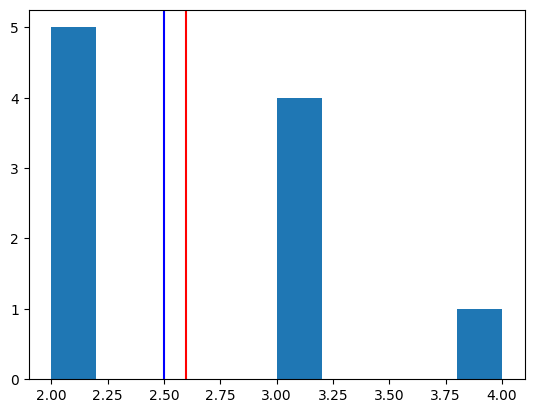

glicina: dif = 0.00


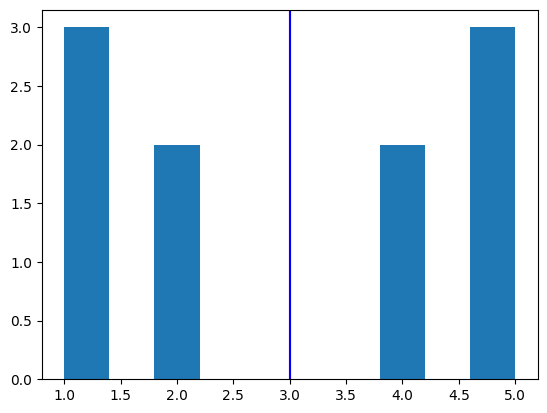

lisina: dif = 0.10


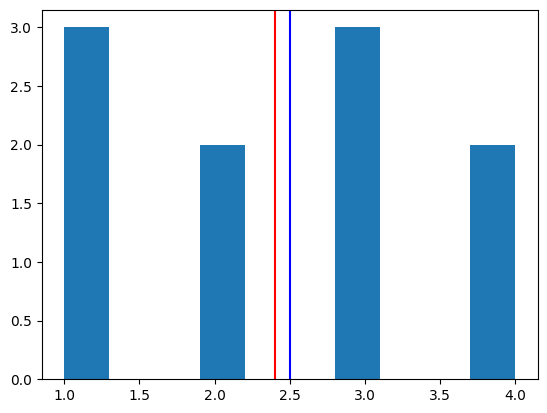

valina: dif = 0.30


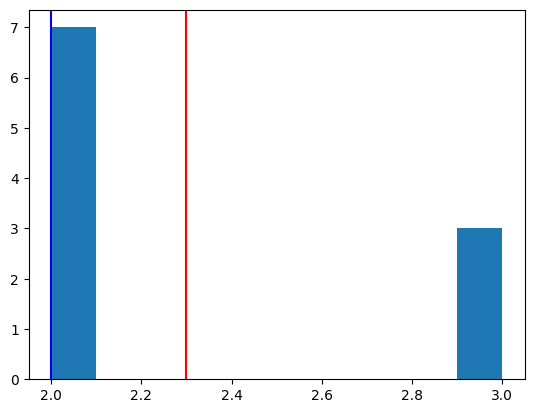

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'glutamina': [2, 3, 2, 4, 3, 2, 3, 2, 3, 2],
    'glicina': [1, 5, 2, 4, 1, 5, 2, 4, 1, 5],
    'lisina': [3, 1, 4, 2, 3, 1, 4, 2, 3, 1],
    'valina': [2, 2, 3, 2, 2, 3, 2, 2, 3, 2]
})

for aa in df.columns:
    print(f"{aa}: dif = {abs(df[aa].mean() - df[aa].median()):.2f}")
    plt.hist(df[aa]); plt.axvline(df[aa].mean(), color='r'); plt.axvline(df[aa].median(), color='b'); plt.show()

## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [6]:
import pandas as pd

df = pd.DataFrame({
    'gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'cisteina': [2, 1, 3, 2, 4]
})

primeiros_genes = df.head(3)
media = primeiros_genes['cisteina'].mean()
mediana = primeiros_genes['cisteina'].median()

print(f"Média: {media}")
print(f"Mediana: {mediana}")

Média: 2.0
Mediana: 2.0


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [7]:
import pandas as pd

df = pd.DataFrame({
    'gene': ['isg15', 'hur', 'ifna', 'tnfa', 'atpsf1a'],
    'cisteina': [2, 1, 3, 2, 4],
    'serina': [3, 2, 1, 3, 2],
    'lisina': [1, 2, 2, 1, 3],
    'valina': [2, 1, 2, 2, 1]
})

df['media'] = df[['cisteina', 'serina', 'lisina', 'valina']].mean(axis=1)
maior = df.loc[df['media'].idxmax()]

print(f"Gene: {maior['gene']}, Média: {maior['media']:.2f}")

Gene: atpsf1a, Média: 2.50


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [8]:
menor = df.loc[df['media'].idxmin()]
print(f"Gene: {menor['gene']}, Média: {menor['media']:.2f}")

Gene: hur, Média: 1.50
